# LLM4Series — Forecasting with an LLM

This notebook shows the end-to-end workflow for using a large language model
to forecast a time series with `llm4series`: data preparation, prompt construction,
model inference, result inspection, and evaluation.

## Step 1 — Import the library and configure the LLM

`ls.LLM` wraps any compatible language model. Pass the model name and
your API key. The key is read from an environment variable to keep credentials
out of the notebook.

In [1]:
import os
import llm4series as ls

# To see the list of supported providers and model naming conventions,
# read: https://docs.litellm.ai/docs/providers
model = ls.LLM(
  model="openai/mistralai/mistral-medium-3.5-128b",
  base_url="https://integrate.api.nvidia.com/v1",
  api_key=os.getenv("OPENAI_API_KEY")
)

## Step 2 — Load and preprocess the data, then split into train and test

Three preprocessing steps are applied conditionally:
- `impute_interpolate` fills missing values only if they exist.
- `agg_duplicates` collapses duplicate timestamps only if they exist.

`ts.split` creates a train window and a test window. `start` and `end`
define the training period; `periods=24` sets the forecast horizon (24 steps ahead).

In [2]:
ts = ls.read_file("data/ETTh2.csv", index_col="date")["OT"]
ts = ts.impute_interpolate("linear") if ts.isna().sum() > 0 else ts
ts = ts.agg_duplicates(method="sum") if ts.index.duplicated().sum() > 0 else ts

train, test = ts.split(
    start="2016-07-12 06:00:00",
    end="2016-09-20 05:00:00",
    periods=24
)

## Step 3 — Build the prompt

`ls.prompt` converts the training data into a structured prompt.
- `type='few_shot'` includes example input-output pairs to guide the model.
- `tsformat='csv'` serializes the time series as comma-separated text.
- `tstype='numeric'` signals that the values are continuous numbers.
- `examples=3` includes three demonstration windows.
- `forecast_horizon=24` tells the model how many steps to predict.

In [3]:
prompt_config = ls.prompt(
    type="few_shot",
    ts=train,
    tsformat="csv",
    tstype="numeric",
    examples=3,
    forecast_horizon=24,
    stl=train.stl(freq="h", period=24) # Optional: STL decomposition to help the model learn the seasonality and trend.
)

## Step 4 — Run the forecast

`model.predict` sends the prompt to the LLM and returns a response object.
The library handles serialization, API calls, and parsing automatically.

In [4]:
response = model.predict(prompt_config)

[INFO] [openai/mistralai/mistral-medium-3.5-128b] Sending request...
[INFO] [openai/mistralai/mistral-medium-3.5-128b] Response received in 40.23s.


## Step 5 — Inspect the prediction

`response.prediction` returns the forecast as a time-indexed DataFrame,
ready for comparison with the test set.

In [5]:
prediction = response.prediction
prediction

date
2016-09-20 06:00:00+00:00    25.576
2016-09-20 07:00:00+00:00    25.576
2016-09-20 08:00:00+00:00    25.796
2016-09-20 09:00:00+00:00    26.675
2016-09-20 10:00:00+00:00    28.433
2016-09-20 11:00:00+00:00    31.069
2016-09-20 12:00:00+00:00    34.146
2016-09-20 13:00:00+00:00    37.222
2016-09-20 14:00:00+00:00    38.979
2016-09-20 15:00:00+00:00    39.859
2016-09-20 16:00:00+00:00    38.759
2016-09-20 17:00:00+00:00    36.782
2016-09-20 18:00:00+00:00    35.025
2016-09-20 19:00:00+00:00    33.706
2016-09-20 20:00:00+00:00    32.168
2016-09-20 21:00:00+00:00    31.069
2016-09-20 22:00:00+00:00    30.191
2016-09-20 23:00:00+00:00    29.312
2016-09-21 00:00:00+00:00    28.652
2016-09-21 01:00:00+00:00    29.092
2016-09-21 02:00:00+00:00    29.312
2016-09-21 03:00:00+00:00    28.652
2016-09-21 04:00:00+00:00    27.773
2016-09-21 05:00:00+00:00    26.895
Name: OT, dtype: float64

## Step 6 — Check latency and token usage

`response.time` gives total inference time in seconds.
`response.input_tokens` and `response.output_tokens` report token counts,
which are directly linked to API cost.

In [6]:
print("Inference Time (s):", response.time)
print("Input Tokens:", response.input_tokens)
print("Output Tokens:", response.output_tokens)

Inference Time (s): 40.23417830467224
Input Tokens: 49376
Output Tokens: 881


## Step 7 — Plot forecast vs. actual

`ls.plot` accepts two series and labels them via `groups`.
This lets you visually compare the real test values against the LLM forecast.

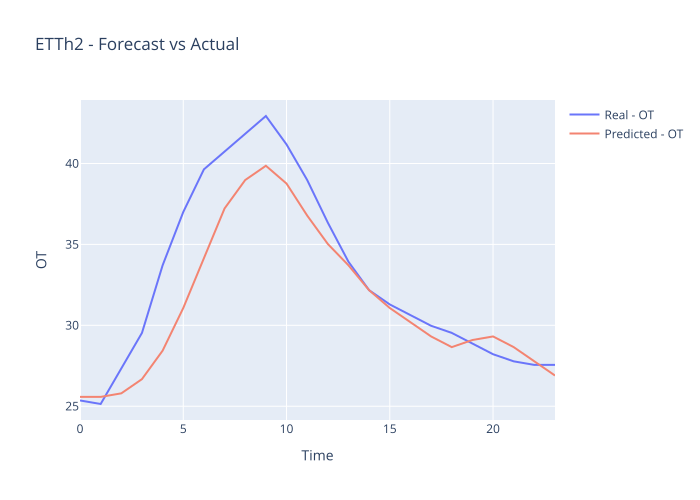

In [7]:
fig = ls.plot(
    test,
    prediction,
    kind='line',
    groups=["Real", "Predicted"],
    title="ETTh2 - Forecast vs Actual",
    xlabel="Time",
    ylabel="OT"
)
fig.show(renderer="svg")

## Step 8 — Evaluate forecast accuracy

`ls.metrics` computes SMAPE, MAE, and RMSE between the predicted and actual series.
Here it is applied to a single variable (`OT`) for a focused evaluation.

In [8]:
ls.metrics(test, prediction)

,OT
smape,5.24
mae,1.78
rmse,2.50
